In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "For variable discovery (judgement ⑩), do the models agree on WHAT fields to extract from patient posts — and how good are the fields they propose (Opus-judged)?"

*Judgement ⑩ of 11 · Track B, step 1. Discovery sets the covariates clustering runs on, so the key question is cross-model divergence, with Opus-as-judge on field quality. Numbers computed from the run.*

In [2]:

import json
from itertools import combinations

RUNS = json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j10_discovery_runs.json", encoding="utf-8"))
MAN = RUNS["manifest"]
proposals, VERD, KNOWN = RUNS["proposals"], RUNS["judge"], RUNS["known_fields"]
CAND = MAN["candidate_models"]
PRICES = {'thinkingmachines/inkling': 1.0, 'openrouter/auto-beta': -1000000.0, 'moonshotai/kimi-k3': 3.0, 'meta/muse-spark-1.1': 1.25, 'kwaipilot/kat-coder-air-v2.5': 0.15, 'kwaipilot/kat-coder-pro-v2.5': 0.74, 'openai/gpt-5.6-luna-pro': 1.0, 'openai/gpt-5.6-luna': 1.0, 'openai/gpt-5.6-terra-pro': 2.5, 'openai/gpt-5.6-terra': 2.5, 'openai/gpt-5.6-sol-pro': 5.0, 'openai/gpt-5.6-sol': 5.0, 'x-ai/grok-4.5': 2.0, '~x-ai/grok-latest': 2.0, 'aion-labs/aion-3.0-mini': 0.7, 'aion-labs/aion-3.0': 3.0, 'tencent/hy3': 0.2, 'tencent/hy3:free': 0.0, 'poolside/laguna-xs-2.1': 0.06, 'poolside/laguna-xs-2.1:free': 0.0, 'anthropic/claude-sonnet-5': 2.0, 'google/gemini-3.1-flash-lite-image': 0.25, 'nex-agi/nex-n2-mini': 0.025, 'sakana/fugu-ultra': 5.0, 'google/gemini-3.1-flash-image': 0.5, 'google/gemini-3-pro-image': 2.0, 'cohere/north-mini-code:free': 0.0, 'z-ai/glm-5.2': 0.904, 'openrouter/fusion': -1000000.0, 'moonshotai/kimi-k2.7-code': 1.0, '~anthropic/claude-fable-latest': 10.0, 'anthropic/claude-fable-5': 10.0, 'nex-agi/nex-n2-pro': 0.25, 'nvidia/nemotron-3.5-content-safety:free': 0.0, 'nvidia/nemotron-3-ultra-550b-a55b': 0.6, 'nvidia/nemotron-3-ultra-550b-a55b:free': 0.0, 'qwen/qwen3.7-plus': 0.32, 'minimax/minimax-m3': 0.3, 'stepfun/step-3.7-flash': 0.2, 'anthropic/claude-opus-4.8-fast': 10.0, 'anthropic/claude-opus-4.8': 5.0, 'qwen/qwen3.7-max': 1.475, 'x-ai/grok-build-0.1': 1.0, 'google/gemini-3.5-flash': 1.5, 'anthropic/claude-opus-4.7-fast': 30.0, 'perceptron/perceptron-mk1': 0.15, 'inclusionai/ring-2.6-1t': 0.075, 'google/gemini-3.1-flash-lite': 0.25, 'openai/gpt-chat-latest': 5.0, 'x-ai/grok-4.3': 1.25, 'ibm-granite/granite-4.1-8b': 0.05, 'mistralai/mistral-medium-3-5': 1.5, 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free': 0.0, 'poolside/laguna-m.1': 0.2, 'poolside/laguna-m.1:free': 0.0, '~anthropic/claude-haiku-latest': 1.0, '~openai/gpt-mini-latest': 0.75, '~google/gemini-pro-latest': 2.0, '~moonshotai/kimi-latest': 3.0, '~google/gemini-flash-latest': 1.5, '~anthropic/claude-sonnet-latest': 2.0, '~openai/gpt-latest': 5.0, 'qwen/qwen3.5-plus-20260420': 0.3, 'qwen/qwen3.6-flash': 0.188, 'qwen/qwen3.6-35b-a3b': 0.14, 'qwen/qwen3.6-max-preview': 1.04, 'qwen/qwen3.6-27b': 0.45, 'openai/gpt-5.5-pro': 30.0, 'openai/gpt-5.5': 5.0, 'deepseek/deepseek-v4-pro': 0.435, 'deepseek/deepseek-v4-flash': 0.098, 'inclusionai/ling-2.6-1t': 0.075, 'tencent/hy3-preview': 0.063, 'xiaomi/mimo-v2.5-pro': 0.435, 'xiaomi/mimo-v2.5': 0.14, 'openai/gpt-5.4-image-2': 8.0, 'inclusionai/ling-2.6-flash': 0.01, '~anthropic/claude-opus-latest': 5.0, 'openrouter/pareto-code': -1000000.0, 'moonshotai/kimi-k2.6': 0.95, 'anthropic/claude-opus-4.7': 5.0, 'z-ai/glm-5.1': 0.966, 'google/gemma-4-26b-a4b-it': 0.1, 'google/gemma-4-26b-a4b-it:free': 0.0, 'google/gemma-4-31b-it': 0.22, 'google/gemma-4-31b-it:free': 0.0, 'qwen/qwen3.6-plus': 0.325, 'z-ai/glm-5v-turbo': 1.2, 'arcee-ai/trinity-large-thinking': 0.25, 'x-ai/grok-4.20-multi-agent': 1.25, 'x-ai/grok-4.20': 1.25, 'google/lyria-3-pro-preview': 0.0, 'google/lyria-3-clip-preview': 0.0, 'kwaipilot/kat-coder-pro-v2': 0.3, 'rekaai/reka-edge': 0.1, 'minimax/minimax-m2.7': 0.25, 'openai/gpt-5.4-nano': 0.2, 'openai/gpt-5.4-mini': 0.75, 'mistralai/mistral-small-2603': 0.15, 'z-ai/glm-5-turbo': 1.2, 'nvidia/nemotron-3-super-120b-a12b': 0.21, 'nvidia/nemotron-3-super-120b-a12b:free': 0.0, 'bytedance-seed/seed-2.0-lite': 0.25, 'qwen/qwen3.5-9b': 0.1, 'openai/gpt-5.4-pro': 30.0, 'openai/gpt-5.4': 2.5, 'inception/mercury-2': 0.25, 'openai/gpt-5.3-chat': 1.75, 'google/gemini-3.1-flash-lite-preview': 0.25, 'bytedance-seed/seed-2.0-mini': 0.1, 'google/gemini-3.1-flash-image-preview': 0.5, 'qwen/qwen3.5-35b-a3b': 0.14, 'qwen/qwen3.5-27b': 0.26, 'qwen/qwen3.5-122b-a10b': 0.26, 'qwen/qwen3.5-flash-02-23': 0.065, 'google/gemini-3.1-pro-preview-customtools': 2.0, 'openai/gpt-5.3-codex': 1.75, 'aion-labs/aion-2.0': 0.8, 'google/gemini-3.1-pro-preview': 2.0, 'anthropic/claude-sonnet-4.6': 3.0, 'qwen/qwen3.5-plus-02-15': 0.26, 'qwen/qwen3.5-397b-a17b': 0.39, 'minimax/minimax-m2.5': 0.15, 'z-ai/glm-5': 0.95, 'qwen/qwen3-max-thinking': 0.78, 'anthropic/claude-opus-4.6': 5.0, 'qwen/qwen3-coder-next': 0.11, 'openrouter/free': 0.0, 'stepfun/step-3.5-flash': 0.1, 'moonshotai/kimi-k2.5': 0.57, 'upstage/solar-pro-3': 0.15, 'minimax/minimax-m2-her': 0.3, 'writer/palmyra-x5': 0.6, 'openai/gpt-audio': 2.5, 'openai/gpt-audio-mini': 0.6, 'z-ai/glm-4.7-flash': 0.061, 'openai/gpt-5.2-codex': 1.75, 'bytedance-seed/seed-1.6-flash': 0.075, 'bytedance-seed/seed-1.6': 0.25, 'minimax/minimax-m2.1': 0.3, 'z-ai/glm-4.7': 0.4, 'google/gemini-3-flash-preview': 0.5, 'nvidia/nemotron-3-nano-30b-a3b': 0.05, 'nvidia/nemotron-3-nano-30b-a3b:free': 0.0, 'openai/gpt-5.2-chat': 1.75, 'openai/gpt-5.2-pro': 21.0, 'openai/gpt-5.2': 1.75, 'mistralai/devstral-2512': 0.4, 'relace/relace-search': 1.0, 'z-ai/glm-4.6v': 0.3, 'openrouter/bodybuilder': -1000000.0, 'openai/gpt-5.1-codex-max': 1.25, 'amazon/nova-2-lite-v1': 0.3, 'mistralai/ministral-14b-2512': 0.2, 'mistralai/ministral-8b-2512': 0.15, 'mistralai/ministral-3b-2512': 0.1, 'mistralai/mistral-large-2512': 0.5, 'deepseek/deepseek-v3.2': 0.269, 'anthropic/claude-opus-4.5': 5.0, 'allenai/olmo-3-32b-think': 0.15, 'google/gemini-3-pro-image-preview': 2.0, 'deepcogito/cogito-v2.1-671b': 1.25, 'openai/gpt-5.1': 1.25, 'openai/gpt-5.1-chat': 1.25, 'openai/gpt-5.1-codex': 1.25, 'openai/gpt-5.1-codex-mini': 0.25, 'moonshotai/kimi-k2-thinking': 0.6, 'amazon/nova-premier-v1': 2.5, 'perplexity/sonar-pro-search': 3.0, 'mistralai/voxtral-small-24b-2507': 0.1, 'openai/gpt-oss-safeguard-20b': 0.075, 'nvidia/nemotron-nano-12b-v2-vl:free': 0.0, 'minimax/minimax-m2': 0.255, 'qwen/qwen3-vl-32b-instruct': 0.104, 'ibm-granite/granite-4.0-h-micro': 0.017, 'openai/gpt-5-image-mini': 2.5, 'anthropic/claude-haiku-4.5': 1.0, 'qwen/qwen3-vl-8b-thinking': 0.117, 'qwen/qwen3-vl-8b-instruct': 0.117, 'openai/gpt-5-image': 10.0, 'openai/o3-deep-research': 10.0, 'openai/o4-mini-deep-research': 2.0, 'google/gemini-2.5-flash-image': 0.3, 'qwen/qwen3-vl-30b-a3b-thinking': 0.13, 'qwen/qwen3-vl-30b-a3b-instruct': 0.13, 'openai/gpt-5-pro': 15.0, 'z-ai/glm-4.6': 0.5, 'anthropic/claude-sonnet-4.5': 3.0, 'deepseek/deepseek-v3.2-exp': 0.27, 'thedrummer/cydonia-24b-v4.1': 0.3, 'relace/relace-apply-3': 0.85, 'qwen/qwen3-vl-235b-a22b-thinking': 0.26, 'qwen/qwen3-vl-235b-a22b-instruct': 0.21, 'qwen/qwen3-max': 0.78, 'qwen/qwen3-coder-plus': 0.65, 'openai/gpt-5-codex': 1.25, 'deepseek/deepseek-v3.1-terminus': 0.27, 'qwen/qwen3-coder-flash': 0.195, 'qwen/qwen3-next-80b-a3b-thinking': 0.098, 'qwen/qwen3-next-80b-a3b-instruct': 0.1, 'qwen/qwen3-next-80b-a3b-instruct:free': 0.0, 'qwen/qwen-plus-2025-07-28': 0.26, 'qwen/qwen-plus-2025-07-28:thinking': 0.26, 'nvidia/nemotron-nano-9b-v2:free': 0.0, 'moonshotai/kimi-k2-0905': 0.6, 'qwen/qwen3-30b-a3b-thinking-2507': 0.13, 'nousresearch/hermes-4-70b': 0.13, 'nousresearch/hermes-4-405b': 1.0, 'deepseek/deepseek-chat-v3.1': 0.25, 'mistralai/mistral-medium-3.1': 0.4, 'z-ai/glm-4.5v': 0.6, 'ai21/jamba-large-1.7': 2.0, 'openai/gpt-5-chat': 1.25, 'openai/gpt-5': 1.25, 'openai/gpt-5-mini': 0.25, 'openai/gpt-5-nano': 0.05, 'openai/gpt-oss-120b': 0.037, 'openai/gpt-oss-20b': 0.03, 'openai/gpt-oss-20b:free': 0.0, 'anthropic/claude-opus-4.1': 15.0, 'mistralai/codestral-2508': 0.3, 'qwen/qwen3-coder-30b-a3b-instruct': 0.07, 'qwen/qwen3-30b-a3b-instruct-2507': 0.1, 'z-ai/glm-4.5': 0.6, 'z-ai/glm-4.5-air': 0.13, 'qwen/qwen3-235b-a22b-thinking-2507': 0.15, 'qwen/qwen3-coder': 0.3, 'qwen/qwen3-coder:free': 0.0, 'bytedance/ui-tars-1.5-7b': 0.1, 'google/gemini-2.5-flash-lite': 0.1, 'qwen/qwen3-235b-a22b-2507': 0.09, 'moonshotai/kimi-k2': 0.57, 'cognitivecomputations/dolphin-mistral-24b-venice-edition': 0.2, 'cognitivecomputations/dolphin-mistral-24b-venice-edition:free': 0.0, 'tencent/hunyuan-a13b-instruct': 0.14, 'morph/morph-v3-large': 0.9, 'morph/morph-v3-fast': 0.8, 'baidu/ernie-4.5-vl-424b-a47b': 0.42, 'mistralai/mistral-small-3.2-24b-instruct': 0.1, 'minimax/minimax-m1': 0.55, 'google/gemini-2.5-flash': 0.3, 'google/gemini-2.5-pro': 1.25, 'openai/o3-pro': 20.0, 'google/gemini-2.5-pro-preview': 1.25, 'deepseek/deepseek-r1-0528': 0.5, 'anthropic/claude-opus-4': 15.0, 'anthropic/claude-sonnet-4': 3.0, 'google/gemma-3n-e4b-it': 0.06, 'mistralai/mistral-medium-3': 0.4, 'google/gemini-2.5-pro-preview-05-06': 1.25, 'arcee-ai/virtuoso-large': 0.75, 'meta-llama/llama-guard-4-12b': 0.18, 'qwen/qwen3-30b-a3b': 0.13, 'qwen/qwen3-8b': 0.117, 'qwen/qwen3-14b': 0.12, 'qwen/qwen3-32b': 0.08, 'qwen/qwen3-235b-a22b': 0.455, 'openai/o4-mini-high': 1.1, 'openai/o3': 2.0, 'openai/o4-mini': 1.1, 'openai/gpt-4.1': 2.0, 'openai/gpt-4.1-mini': 0.4, 'openai/gpt-4.1-nano': 0.1, 'meta-llama/llama-4-maverick': 0.2, 'meta-llama/llama-4-scout': 0.1, 'deepseek/deepseek-chat-v3-0324': 0.27, 'openai/o1-pro': 150.0, 'mistralai/mistral-small-3.1-24b-instruct': 0.351, 'google/gemma-3-4b-it': 0.05, 'google/gemma-3-12b-it': 0.05, 'cohere/command-a': 2.5, 'openai/gpt-4o-mini-search-preview': 0.15, 'openai/gpt-4o-search-preview': 2.5, 'rekaai/reka-flash-3': 0.1, 'google/gemma-3-27b-it': 0.1, 'thedrummer/skyfall-36b-v2': 0.55, 'perplexity/sonar-reasoning-pro': 2.0, 'perplexity/sonar-pro': 3.0, 'perplexity/sonar-deep-research': 2.0, 'mistralai/mistral-saba': 0.2, 'openai/o3-mini-high': 1.1, 'aion-labs/aion-rp-llama-3.1-8b': 0.8, 'qwen/qwen2.5-vl-72b-instruct': 0.8, 'qwen/qwen-plus': 0.26, 'openai/o3-mini': 1.1, 'mistralai/mistral-small-24b-instruct-2501': 0.05, 'perplexity/sonar': 1.0, 'deepseek/deepseek-r1-distill-llama-70b': 0.8, 'deepseek/deepseek-r1': 0.7, 'minimax/minimax-01': 0.2, 'microsoft/phi-4': 0.07, 'deepseek/deepseek-chat': 0.2, 'sao10k/l3.3-euryale-70b': 0.65, 'openai/o1': 15.0, 'cohere/command-r7b-12-2024': 0.037, 'meta-llama/llama-3.3-70b-instruct': 0.13, 'meta-llama/llama-3.3-70b-instruct:free': 0.0, 'amazon/nova-lite-v1': 0.06, 'amazon/nova-micro-v1': 0.035, 'amazon/nova-pro-v1': 0.8, 'openai/gpt-4o-2024-11-20': 2.5, 'mistralai/mistral-large-2407': 2.0, 'qwen/qwen-2.5-coder-32b-instruct': 0.66, 'thedrummer/unslopnemo-12b': 0.4, 'anthracite-org/magnum-v4-72b': 3.0, 'qwen/qwen-2.5-7b-instruct': 0.04, 'inflection/inflection-3-pi': 2.5, 'inflection/inflection-3-productivity': 2.5, 'thedrummer/rocinante-12b': 0.25, 'meta-llama/llama-3.2-1b-instruct': 0.027, 'meta-llama/llama-3.2-3b-instruct': 0.051, 'meta-llama/llama-3.2-3b-instruct:free': 0.0, 'qwen/qwen-2.5-72b-instruct': 0.36, 'cohere/command-r-08-2024': 0.15, 'cohere/command-r-plus-08-2024': 2.5, 'sao10k/l3.1-euryale-70b': 0.85, 'nousresearch/hermes-3-llama-3.1-70b': 0.7, 'nousresearch/hermes-3-llama-3.1-405b': 1.0, 'nousresearch/hermes-3-llama-3.1-405b:free': 0.0, 'sao10k/l3-lunaris-8b': 0.04, 'openai/gpt-4o-2024-08-06': 2.5, 'meta-llama/llama-3.1-70b-instruct': 0.4, 'meta-llama/llama-3.1-8b-instruct': 0.05, 'mistralai/mistral-nemo': 0.019, 'openai/gpt-4o-mini': 0.15, 'openai/gpt-4o-mini-2024-07-18': 0.15, 'google/gemma-2-27b-it': 0.65, 'openai/gpt-4o': 2.5, 'openai/gpt-4o-2024-05-13': 5.0, 'mistralai/mixtral-8x22b-instruct': 2.0, 'microsoft/wizardlm-2-8x22b': 0.62, 'openai/gpt-4-turbo': 10.0, 'anthropic/claude-3-haiku': 0.25, 'mistralai/mistral-large': 2.0, 'openai/gpt-3.5-turbo-0613': 1.0, 'openai/gpt-4-turbo-preview': 10.0, 'openrouter/auto': -1000000.0, 'openai/gpt-3.5-turbo-instruct': 1.5, 'openai/gpt-3.5-turbo-16k': 3.0, 'mancer/weaver': 0.5, 'undi95/remm-slerp-l2-13b': 0.45, 'gryphe/mythomax-l2-13b': 0.06, 'openai/gpt-3.5-turbo': 0.5, 'openai/gpt-4': 30.0}
def short(m): return m.split("/")[-1]
def jacc(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if (a | b) else np.nan

# per-model proposed field set (union across batches)
fset = {m: set() for m in CAND}
for p in proposals:
    fset[p["model"]].update(f["field_name"] for f in p["fields"])

# how many models proposed each field (consensus), and its Opus verdict
from collections import Counter
prop_count = Counter()
for m in CAND:
    prop_count.update(fset[m])
ALLF = sorted(prop_count)

mr = []
for m in CAND:
    fs = fset[m]
    kept = sum(1 for f in fs if VERD.get(f) == "keep")
    mr.append(dict(model=m, mshort=short(m), n_fields=len(fs), n_kept=kept,
                   precision=(kept / len(fs) if fs else np.nan), price=PRICES.get(m, np.nan)))
MS = pd.DataFrame(mr)
FAILED = MS[MS.n_fields == 0].mshort.tolist()
MS = MS[MS.n_fields > 0].reset_index(drop=True)
OK = MS.model.tolist()

# N×N divergence of proposed field sets
MAT = pd.DataFrame(index=[short(m) for m in OK], columns=[short(m) for m in OK], dtype=float)
for x in OK:
    for y in OK:
        MAT.loc[short(x), short(y)] = 1.0 if x == y else jacc(fset[x], fset[y])
MS["outlier"] = [1 - np.nanmean([MAT.loc[short(m), short(o)] for o in OK if o != m]) for m in OK]

n_kept_total = sum(1 for f in ALLF if VERD.get(f) == "keep")
_lo, _hi = MS.sort_values("n_fields").iloc[0], MS.sort_values("n_fields").iloc[-1]
_meanov = np.nanmean(MAT.values[np.triu_indices(len(OK), 1)]) if len(OK) > 1 else np.nan
display(Markdown(f"""
**Abstract.** Variable discovery (judgement ⑩) is Track B's first step: a model reads patient posts and
proposes NEW fields to extract, beyond the fixed {MAN['n_known_fields']}-field schema. These become the
covariates clustering runs on — so if models disagree on *what* to extract, the clustering axes are
themselves model-dependent. Across **{len(OK)} models** on {MAN['n_posts']} posts (temp 0), the field
count ranges from **{int(_lo.n_fields)} ({_lo.mshort})** to **{int(_hi.n_fields)} ({_hi.mshort})** — a
{_hi.n_fields / max(_lo.n_fields,1):.0f}× spread — and the models share only a mean **{_meanov:.0%}** of
their proposed fields. Opus-as-judge keeps {MS.n_kept.sum()} of {len(ALLF)} distinct proposals as
genuinely useful covariates; per-model keep-rate (precision) ranges {MS.precision.min():.0%}–{MS.precision.max():.0%}.
The lesson the plan drew — freeze **Opus's** field set rather than any consensus — is exactly what this
divergence forces.{(' No parseable fields from: ' + ', '.join(FAILED) + '.') if FAILED else ''}
"""))



**Abstract.** Variable discovery (judgement ⑩) is Track B's first step: a model reads patient posts and
proposes NEW fields to extract, beyond the fixed 37-field schema. These become the
covariates clustering runs on — so if models disagree on *what* to extract, the clustering axes are
themselves model-dependent. Across **22 models** on 24 posts (temp 0), the field
count ranges from **12 (glm-5.2)** to **106 (claude-haiku-4.5)** — a
9× spread — and the models share only a mean **1%** of
their proposed fields. Opus-as-judge keeps 409 of 1003 distinct proposals as
genuinely useful covariates; per-model keep-rate (precision) ranges 6%–52%.
The lesson the plan drew — freeze **Opus's** field set rather than any consensus — is exactly what this
divergence forces.


## 1. What this judgement is, and why divergence matters

`discover_fields.py` asks a model to read patient posts and propose *new* structured fields worth extracting (beyond the fixed schema) — things like `functional_status_tier` or `infection_count`. Those proposed fields become the **covariates the clustering runs on**. Unlike drug-ID, there is no single right field set — but if two models propose wildly different fields, the *axes of the clustering* are model-dependent, which is a validity problem before any cluster is computed. So the question is two-part: do models **agree** on what to extract, and are the fields they propose **good** (Opus-judged)?

## 2. The divergence — models do not agree on what to extract

First, how many fields each model proposes on the same posts. Eli's earlier benchmark found order-of-magnitude spreads; here it is directly measured.

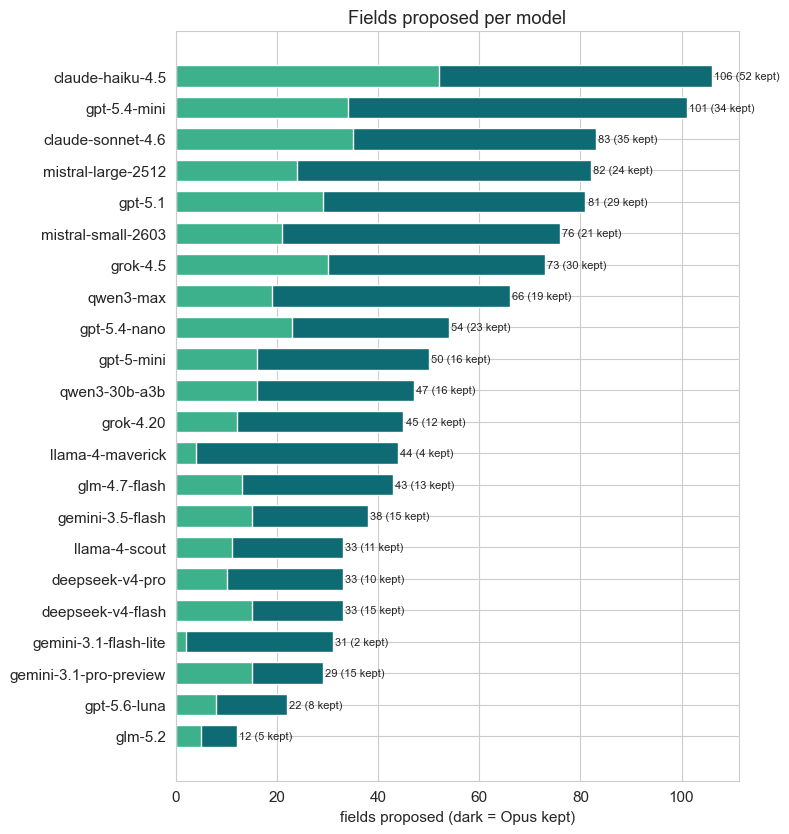

**What this shows:** the field count ranges **12–106** across the roster — a 9× spread on identical input. Models don't disagree at the margin; they disagree on the whole scope of what a patient record should capture.

In [3]:

d = MS.sort_values("n_fields")
fig, ax = plt.subplots(figsize=(8, 0.34*len(d) + 1))
ax.barh(d.mshort, d.n_fields, color="#0e6b74", height=0.68)
ax.barh(d.mshort, d.n_kept, color="#3cb18c", height=0.68)
for y, (_, r) in enumerate(d.iterrows()):
    ax.text(r.n_fields + 0.4, y, f"{int(r.n_fields)} ({int(r.n_kept)} kept)", va="center", fontsize=8)
ax.set_xlabel("fields proposed (dark = Opus kept)"); ax.set_title("Fields proposed per model")
fig.tight_layout(); plt.show()
display(Markdown(
  f"**What this shows:** the field count ranges **{int(MS.n_fields.min())}–{int(MS.n_fields.max())}** across "
  f"the roster — a {MS.n_fields.max()/max(MS.n_fields.min(),1):.0f}× spread on identical input. Models don't "
  f"disagree at the margin; they disagree on the whole scope of what a patient record should capture."))


## 3. Quality — Opus-judge keep-rate

Volume isn't value. Opus rules each proposed field keep (a distinct, well-defined, research-useful covariate) or junk (redundant / vague / not biomedical). Precision = fraction of a model's proposals Opus keeps.

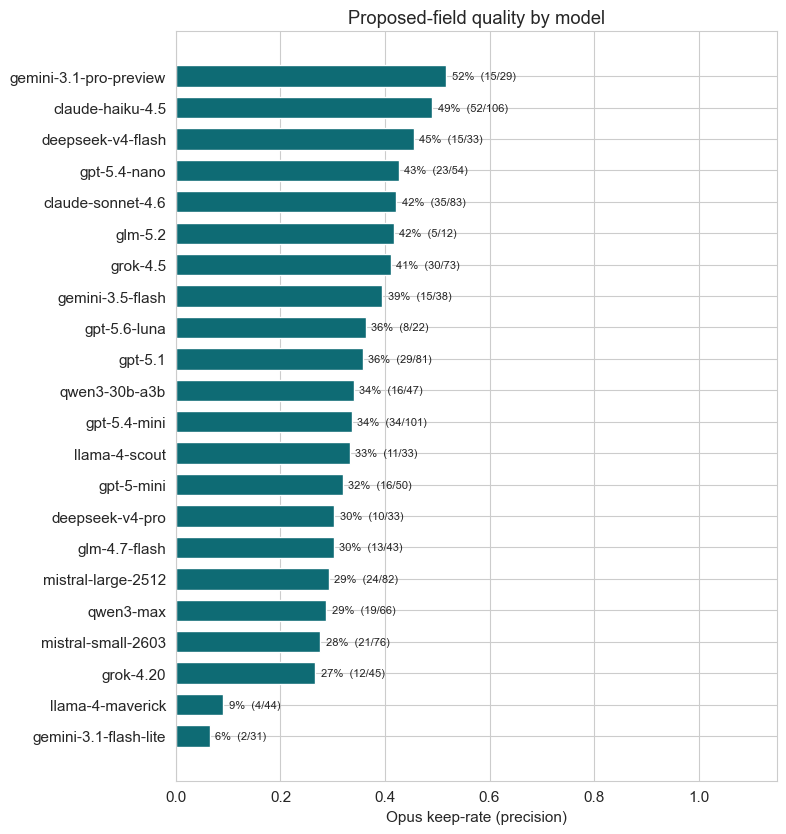

model,proposed,kept,keep-rate,divergence,$/1M in
claude-haiku-4.5,106,52,49%,0.99,$1
claude-sonnet-4.6,83,35,42%,0.98,$3
gpt-5.4-mini,101,34,34%,0.99,$0.75
grok-4.5,73,30,41%,0.98,$2
gpt-5.1,81,29,36%,0.99,$1.25
mistral-large-2512,82,24,29%,0.98,$0.5
gpt-5.4-nano,54,23,43%,0.99,$0.2
mistral-small-2603,76,21,28%,0.99,$0.15
qwen3-max,66,19,29%,0.98,$0.78
gpt-5-mini,50,16,32%,0.98,$0.25


In [4]:

d = MS.sort_values("precision")
fig, ax = plt.subplots(figsize=(8, 0.34*len(d) + 1))
ax.barh(d.mshort, d.precision, color="#0e6b74", height=0.68)
for y, (_, r) in enumerate(d.iterrows()):
    ax.text(r.precision + 0.01, y, f"{r.precision:.0%}  ({int(r.n_kept)}/{int(r.n_fields)})", va="center", fontsize=8)
ax.set_xlim(0, 1.15); ax.set_xlabel("Opus keep-rate (precision)"); ax.set_title("Proposed-field quality by model")
fig.tight_layout(); plt.show()
tbl = MS.sort_values("n_kept", ascending=False)[["mshort","n_fields","n_kept","precision","outlier","price"]].copy()
tbl["precision"] = (tbl["precision"]*100).round(0).astype("Int64").astype(str)+"%"
tbl["outlier"] = tbl["outlier"].round(2)
tbl["price"] = tbl["price"].map(lambda v: f"${v:g}" if pd.notna(v) else "?")
tbl.columns = ["model","proposed","kept","keep-rate","divergence","$/1M in"]
display(HTML("<b>Discovery scorecard</b>" + tbl.to_html(index=False)))


## 4. Which models find the valuable fields — and which find them alone

Count and keep-rate don't say whether models find the *same* good fields or *different* ones. Looking only at the valid (Opus-kept) fields: is there a shared core every model catches, or does each model contribute its own slice? This is what decides whether discovery is a job for one model or an ensemble.

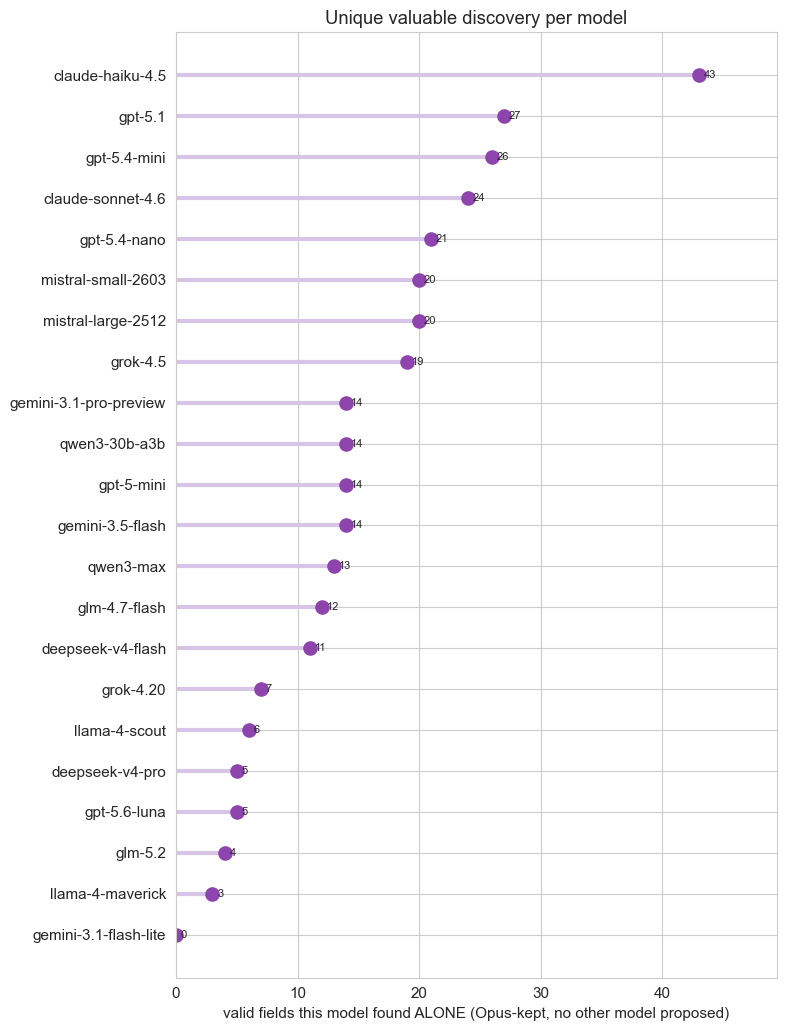

**What this shows:** there is **no shared core** — of 355 Opus-kept fields, only **0** were proposed by >=6 of 22 models, and **322** were seen by a single model. Each model contributes a different valid slice: **claude-haiku-4.5** alone surfaced **43** valid covariates no other model found, while gemini-3.1-flash-lite added 0. So discovery models are **complementary, not rankable** — the fullest field set comes from unioning several, and a thorough model is worth keeping in a discovery ensemble even if its keep-rate is only middling.

valid field found by ONE model only,the model
ableism_and_weight_stigma_experience,gpt-5.1
acute_infection_symptom_remission,gemini-3.5-flash
adaptive_equipment_strategy,gemini-3.1-pro-preview
adl_limitation,gemini-3.1-pro-preview
affected_body_part,gemini-3.1-pro-preview
affective_blunting,grok-4.5
age_at_infection,deepseek-v4-pro
air_quality_management,llama-4-scout
allergic_sensitization_timing,mistral-small-2603
allergy_progression_trajectory,claude-haiku-4.5


In [5]:

kept = set(f for f in prop_count if VERD.get(f) == "keep")
K = 6
core = [f for f in kept if prop_count[f] >= K]
uq = (pd.DataFrame([(short(m), sum(1 for f in fset[m] if f in kept and prop_count[f] == 1)) for m in OK],
                   columns=["mshort", "n_unique"]).sort_values("n_unique"))
ys = np.arange(len(uq))
fig, ax = plt.subplots(figsize=(8, 1.2 + 0.42*len(uq)))
ax.hlines(ys, 0, uq.n_unique, color="#d7c4e6", lw=3, zorder=1)
ax.scatter(uq.n_unique, ys, color="#8e44ad", s=90, zorder=2)
for y, v in zip(ys, uq.n_unique):
    ax.text(v + 0.4, y, str(int(v)), va="center", fontsize=8)
ax.set_yticks(ys); ax.set_yticklabels(uq.mshort); ax.set_xlim(0, max(uq.n_unique.max()*1.15, 1))
ax.set_xlabel("valid fields this model found ALONE (Opus-kept, no other model proposed)")
ax.set_title("Unique valuable discovery per model")
fig.tight_layout(); plt.show()

from collections import Counter as _C
covdist = _C(prop_count[f] for f in kept)
solo = [(f, next(short(m) for m in OK if f in fset[m])) for f in sorted(kept) if prop_count[f] == 1]
display(Markdown(
  f"**What this shows:** there is **no shared core** — of {len(kept)} Opus-kept fields, only **{len(core)}** were "
  f"proposed by >={K} of {len(OK)} models, and **{covdist.get(1,0)}** were seen by a single model. Each model "
  f"contributes a different valid slice: **{uq.iloc[-1].mshort}** alone surfaced **{int(uq.iloc[-1].n_unique)}** "
  f"valid covariates no other model found, while {uq.iloc[0].mshort} added {int(uq.iloc[0].n_unique)}. So "
  f"discovery models are **complementary, not rankable** — the fullest field set comes from unioning several, "
  f"and a thorough model is worth keeping in a discovery ensemble even if its keep-rate is only middling."))
ex = pd.DataFrame(solo[:14], columns=["valid field found by ONE model only", "the model"])
display(HTML("<b>Differentiators — valuable covariates a single model caught</b>" + ex.to_html(index=False)))


## 5. Counterintuitive: more fields is not more signal

The intuition is that a model proposing more fields is more thorough. The data says the extra fields are disproportionately junk — volume trades against precision — and the fields that survive are the ones many models independently converge on.

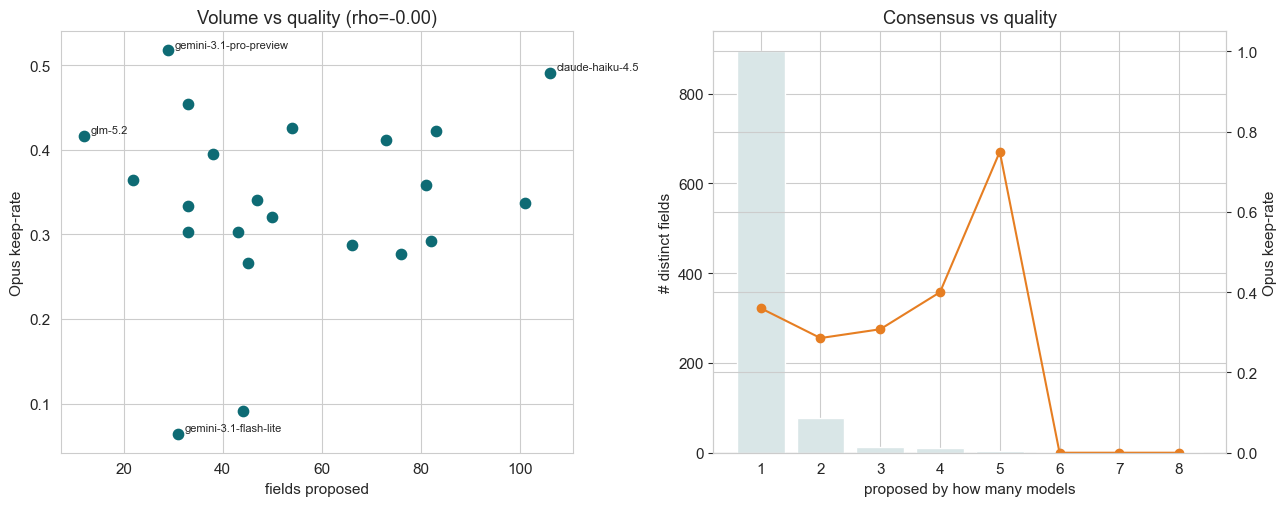

**What this shows:** volume trends against quality (Spearman rho=-0.00). **894 of 1003** distinct fields were proposed by just ONE model — the long tail of idiosyncratic ideas — and Opus keeps only 36% of those, versus a higher rate for fields multiple models converge on. Agreement tracks quality; idiosyncrasy tracks junk.

In [6]:

fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
# left: n_fields vs precision
ax[0].scatter(MS.n_fields, MS.precision, s=55, color="#0e6b74", zorder=3)
for i in {MS.n_fields.idxmax(), MS.n_fields.idxmin(), MS.precision.idxmax(), MS.precision.idxmin()}:
    r = MS.loc[i]; ax[0].annotate(r.mshort, (r.n_fields, r.precision), fontsize=8, xytext=(5,2), textcoords="offset points")
from scipy.stats import spearmanr
rho, prho = spearmanr(MS.n_fields, MS.precision)
ax[0].set_xlabel("fields proposed"); ax[0].set_ylabel("Opus keep-rate"); ax[0].set_title(f"Volume vs quality (rho={rho:.2f})")
# right: consensus — of fields proposed by k models, what fraction does Opus keep?
kbins = {}
for f in ALLF:
    k = prop_count[f]; kbins.setdefault(k, [0,0]); kbins[k][0]+=1; kbins[k][1]+= (VERD.get(f)=="keep")
ks = sorted(kbins); keeprate=[kbins[k][1]/kbins[k][0] for k in ks]; counts=[kbins[k][0] for k in ks]
ax2b = ax[1].twinx()
ax[1].bar(ks, counts, color="#d9e6e7", label="# fields")
ax2b.plot(ks, keeprate, "-o", color="#e67e22", label="Opus keep-rate")
ax[1].set_xlabel("proposed by how many models"); ax[1].set_ylabel("# distinct fields"); ax2b.set_ylabel("Opus keep-rate"); ax2b.set_ylim(0,1.05)
ax[1].set_title("Consensus vs quality")
fig.tight_layout(); plt.show()
_single = sum(1 for f in ALLF if prop_count[f]==1); _singlekeep = sum(1 for f in ALLF if prop_count[f]==1 and VERD.get(f)=="keep")
display(Markdown(
  f"**What this shows:** volume trends {'against' if rho<0 else 'with'} quality (Spearman rho={rho:.2f}). "
  f"**{_single} of {len(ALLF)}** distinct fields were proposed by just ONE model — the long tail of "
  f"idiosyncratic ideas — and Opus keeps only {_singlekeep/_single:.0%} of those, versus a higher rate for "
  f"fields multiple models converge on. Agreement tracks quality; idiosyncrasy tracks junk."))


## 6. Divergence map & the frozen-GT implication

The pairwise overlap of proposed field sets, and why this settles the design choice: with this little agreement, a consensus field set would keep only the trivially-obvious fields. Freezing **Opus's** reviewed set (the plan's call) is what the divergence forces.

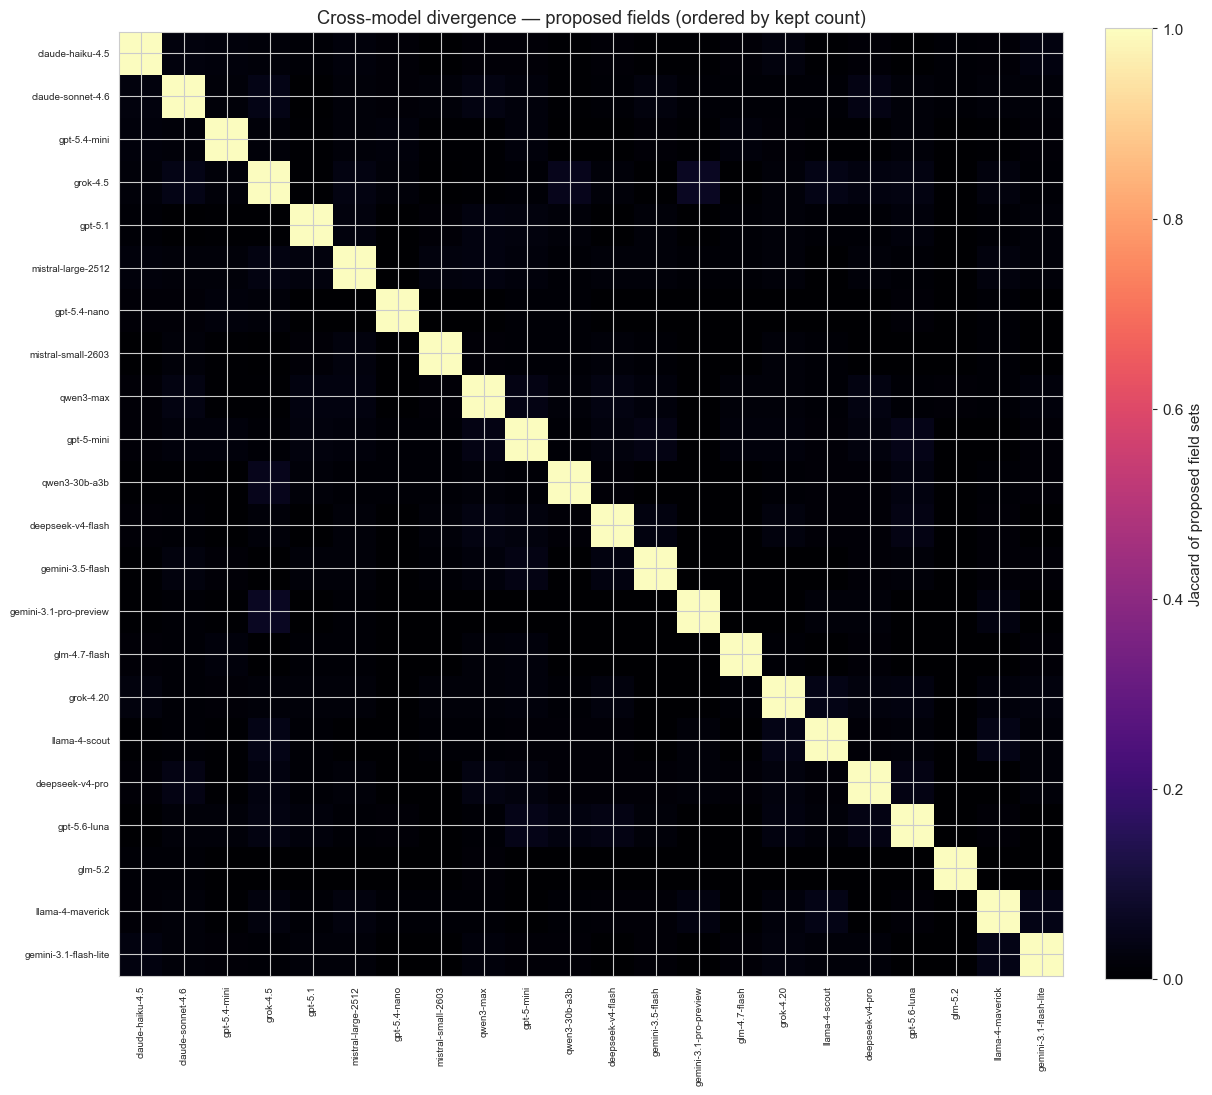

**What this shows:** models share a mean **1%** of their proposed fields — far below the extraction overlap in ②. There is no consensus field set to freeze; a majority-vote schema would discard almost everything. This is the empirical case for the plan's decision: the frozen target is **Opus's reviewed field set**, and cheap models are scored on how well they recover it — not on what they agree with each other about.

In [7]:

order = MS.sort_values("n_kept", ascending=False).mshort.tolist()
M = MAT.reindex(index=order, columns=order).astype(float)
fig, ax = plt.subplots(figsize=(0.42*len(order)+3, 0.42*len(order)+2))
im = ax.imshow(M.values, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Jaccard of proposed field sets")
ax.set_title("Cross-model divergence — proposed fields (ordered by kept count)")
fig.tight_layout(); plt.show()
mean_ov = np.nanmean(MAT.values[np.triu_indices(len(order),1)])
display(Markdown(
  f"**What this shows:** models share a mean **{mean_ov:.0%}** of their proposed fields — far below the "
  f"extraction overlap in ②. There is no consensus field set to freeze; a majority-vote schema would "
  f"discard almost everything. This is the empirical case for the plan's decision: the frozen target is "
  f"**Opus's reviewed field set**, and cheap models are scored on how well they recover it — not on what "
  f"they agree with each other about."))


## 7. Conclusion

Discovery is the highest-variance judgement in the pipeline, and that variance is the finding.

In [8]:

lines = [
  f"- **No agreement on scope.** Field counts span {int(MS.n_fields.min())}–{int(MS.n_fields.max())} and "
  f"models share only ~{np.nanmean(MAT.values[np.triu_indices(len(MS),1)]):.0%} of proposals — the covariate "
  f"set is model-dependent, so discovery cannot be left to any single cheap model or to consensus.",
  f"- **Quality is judgeable even when scope isn't.** Opus keeps {MS.n_kept.sum()} of {len(ALLF)} distinct "
  f"proposals; the highest keep-rate is {MS.sort_values('precision',ascending=False).iloc[0].mshort} "
  f"({MS.precision.max():.0%}).",
  f"- **Freeze Opus's set.** With this divergence, the design must define the target as Opus's reviewed field "
  f"set (a frozen GT), then score cheap models on recovery — which is judgement ⑪'s schema.",
  f"- **Consensus ≈ quality.** Fields multiple models converge on are the ones Opus keeps; singletons are "
  f"mostly junk — a cheap heuristic for pruning discovery output.",
]
display(Markdown("### Verdict\n\n" + "\n".join(lines)))


### Verdict

- **No agreement on scope.** Field counts span 12–106 and models share only ~1% of proposals — the covariate set is model-dependent, so discovery cannot be left to any single cheap model or to consensus.
- **Quality is judgeable even when scope isn't.** Opus keeps 409 of 1003 distinct proposals; the highest keep-rate is gemini-3.1-pro-preview (52%).
- **Freeze Opus's set.** With this divergence, the design must define the target as Opus's reviewed field set (a frozen GT), then score cheap models on recovery — which is judgement ⑪'s schema.
- **Consensus ≈ quality.** Fields multiple models converge on are the ones Opus keeps; singletons are mostly junk — a cheap heuristic for pruning discovery output.

## 8. Research limitations

- **No frozen GT yet.** Correctness here is Opus-as-judge on field *quality* (keep/junk), not recovery of a
  frozen Opus field set — that GT is the next fixture (it is exactly what ⑪ needs). So this measures whether
  a proposed field is *good*, not whether a model recovered *the* target set.
- **Field-name matching is exact (normalized).** Near-duplicate names ("fatigue_severity" vs "fatigue_level")
  count as different fields, which inflates divergence — but that models don't even converge on naming is
  itself part of the finding.
- **Opus-as-judge is silver** and reviews its own descriptions; a second frontier reviewer (the GT step)
  would tighten the quality call.
- **Sample** is a fixed slice of long-COVID posts; discovered fields are corpus-specific.
- Measures the correctness/stability of a measurement step, not any treatment effect.

In [9]:

import hashlib as _h
try: _sha = _h.sha256(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db","rb").read()).hexdigest()[:16]
except Exception: _sha = "n/a"
prov = pd.DataFrame({
  "item": ["run generated (UTC)","judgement","candidate models","judge (truth)","posts / batches",
           "known schema fields","temperature","skill version"],
  "value": [MAN["generated_utc"], MAN["judgement"], f'{len(CAND)} ({len(OK)} produced fields)',
            MAN["judge_model"], f'{MAN["n_posts"]} / {MAN["n_batches"]}', MAN["n_known_fields"],
            MAN["temperature"], "research-assistant v2"],
})
display(HTML("<b>Provenance</b>" + prov.to_html(index=False)))
display(HTML('<div style="font-size:1.2em;font-weight:bold;font-style:italic;margin-top:1em">'
             'These findings reflect the behaviour of a measurement pipeline and model knowledge, not '
             'population-level treatment effects. This is not medical advice.</div>'))


item,value
run generated (UTC),2026-07-18T00:58:43.002126+00:00
judgement,10_variable_discovery
candidate models,22 (22 produced fields)
judge (truth),anthropic/claude-opus-4.8
posts / batches,24 / 9
known schema fields,37
temperature,0.0
skill version,research-assistant v2
